## RQ1: Predictive Performance & Key Lending Drivers
#### Group 6 | Francesco Biedermann (FB2709) | Brian Hsu (CH4004) | Phoebe Zhao (PYZ2001) 
#### APAN5205 Applied Machine Learning 2 | Prof. Andrew Assing

This notebook addresses Research Question 1: *"To what extent can mortgage approval outcomes be predicted using applicant, loan, and property characteristics available at the time of application, and which factors appear to play the largest role in these decisions?"*

We train and compare three classification models:
- Logistic Regression (with Lasso and Ridge regularization)
- Decision Tree
- Random Forest (using 5-fold cross-validation for hyperparameter tuning)

Demographic variables are excluded from the predictive models and reserved for the fairness analysis in RQ2.

### Step 1 | Setup and Data Loading
We begin by importing the required libraries and loading the cleaned HMDA dataset produced during data preparation. The dataset contains 433,173 mortgage application records with 32 columns and zero missing values.

In [1]:
# Step 1: Setup and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay

# Load cleaned data
df = pd.read_csv('../data/hmda_2024_cleaned.csv')

print('Dataset shape:', df.shape)
print('Approval rate:', round(df['approved'].mean()*100, 2), '%')
print('\nTarget distribution:')
print(df['approved'].value_counts())

Dataset shape: (433173, 32)
Approval rate: 77.36 %

Target distribution:
approved
1    335087
0     98086
Name: count, dtype: int64


**Observations:** The dataset contains 433,173 mortgage applications with a 77.36% approval rate.

### Step 2 | Feature Selection and Preparation
We separate the target variable from the features and apply several preparation steps:

- **Demographic exclusion:** The derived race, ethnicity, and sex columns are excluded from the predictive models, consistent with our research design. These variables are reserved for the fairness analysis in RQ2.
- **Constant feature removal:** The `reverse_mortgage` column contains only a single value (2) after data cleaning and provides no discriminative information. It is dropped.
- **Leakage removal:** The `interest_rate_missing` flag is excluded. During data cleaning, we found that interest rates are only assigned after an application is approved, which means this flag is missing for nearly 100% of denied applications. Including it would allow the model to trivially predict the outcome rather than learning meaningful patterns from application-time features. The remaining missingness flags for debt-to-income ratio and combined loan-to-value ratio are retained, as their missingness patterns are not structurally determined by the outcome.
- **One-hot encoding:** The `state_code` column (54 U.S. states and territories) is one-hot encoded with `drop_first=True` to avoid multicollinearity.

In [2]:
# Step 2: Feature Selection and Preparation

# Define target
y = df['approved']

# Columns to exclude from modeling
drop_cols = [
    'approved',                # target variable
    'derived_race',            # reserved for RQ2
    'derived_ethnicity',       # reserved for RQ2
    'derived_sex',             # reserved for RQ2
    'reverse_mortgage',        # constant (only one unique value)
    'interest_rate_missing'    # leaky: determined by the outcome
]

X = df.drop(columns=drop_cols)

print('Dropping reverse_mortgage — only one unique value:', df['reverse_mortgage'].unique())
print('Dropping interest_rate_missing — near-perfect proxy for approval status')

# One-hot encode state_code
X = pd.get_dummies(X, columns=['state_code'], drop_first=True)

print('\nFeature matrix shape:', X.shape)
print('Number of features:', X.shape[1])

Dropping reverse_mortgage — only one unique value: [2]
Dropping interest_rate_missing — near-perfect proxy for approval status

Feature matrix shape: (433173, 78)
Number of features: 78


**Observations:** After excluding demographic variables, the constant `reverse_mortgage` column and the leaky `interest_rate_missing` flag, we are left with 78 features (25 core features plus 53 state dummy variables).

### Step 3 | Train-Test Split and Scaling
We split the data 70/30 into training and test sets, stratifying on the target variable to preserve the approval rate in both partitions. We also draw a stratified subsample of 50,000 rows from the training set for hyperparameter tuning, as running 5-fold cross-validation on 300,000+ rows would be computationally prohibitive. Once the best hyperparameters are identified, the final models are trained on the full training set.

We standardize features using `StandardScaler` for use with Logistic Regression. Because Logistic Regression with L1 and L2 regularization applies a penalty to the coefficients, features must be on the same scale for the penalty to be applied uniformly. The scaler is fit on the training data and applied to both training and test sets to prevent data leakage. Decision Trees and Random Forests are not affected by feature scale and are trained on unscaled data.

In [3]:
# Step 3: Train-Test Split and Scaling

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print('Training set:', X_train.shape[0], 'rows')
print('Test set:    ', X_test.shape[0], 'rows')
print('Approval rate - Train:', round(y_train.mean()*100, 2), '%')
print('Approval rate - Test: ', round(y_test.mean()*100, 2), '%')

# Standardize features for Logistic Regression (fit on train, transform both)
scale = StandardScaler()
scale.fit(X_train)
X_train_scaled = scale.transform(X_train)
X_test_scaled = scale.transform(X_test)

print('\nStandardScaler applied for Logistic Regression.')

# Subsample for hyperparameter tuning (full training set is too large for CV)
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train, train_size=50000, random_state=42, stratify=y_train
)

# Scaled version of tuning subsample
X_tune_scaled = scale.transform(X_tune)

print('Tuning subsample:', X_tune.shape[0], 'rows')
print('Approval rate - Tuning:', round(y_tune.mean()*100, 2), '%')

Training set: 303221 rows
Test set:     129952 rows
Approval rate - Train: 77.36 %
Approval rate - Test:  77.36 %

StandardScaler applied for Logistic Regression.
Tuning subsample: 50000 rows
Approval rate - Tuning: 77.36 %


### Step 4a | Model 1: Logistic Regression (Ridge)
We train Logistic Regression with L2 (Ridge) regularization on the standardized features, tuning the regularization strength via 5-fold cross-validation. Ridge shrinks all coefficients toward zero without eliminating them, which can improve generalization when many features are moderately important.

In [4]:
# Step 4a: Logistic Regression — L2 (Ridge) on scaled data

logit_l2 = LogisticRegression(max_iter=10000, penalty='l2', random_state=42)

param_grid_l2 = {'C': [0.01, 0.1, 1, 10]}

tune_logit_l2 = GridSearchCV(
    estimator=logit_l2,
    param_grid=param_grid_l2,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

tune_logit_l2.fit(X_tune_scaled, y_tune)

print('L2 (Ridge) Results:')
print('Best C:', tune_logit_l2.best_params_['C'])
print('Best CV AUC-ROC:', round(tune_logit_l2.best_score_, 4))

# Show all CV results
cv_l2 = pd.DataFrame(tune_logit_l2.cv_results_)
print('\nAll results:')
print(cv_l2[['param_C', 'mean_test_score', 'std_test_score']].to_string(index=False))

L2 (Ridge) Results:
Best C: 0.1
Best CV AUC-ROC: 0.7866

All results:
 param_C  mean_test_score  std_test_score
    0.01         0.786559        0.003862
    0.10         0.786568        0.003928
    1.00         0.786529        0.003925
   10.00         0.786510        0.003933


**Observations:** The L2 (Ridge) Logistic Regression achieves a best CV AUC-ROC of 0.7866 with C=0.1. Performance is quite stable across all C values (ranging from 0.7866 to 0.7865), suggesting the model is not highly sensitive to the regularization strength. This stability indicates that the features are well-behaved and that moderate regularization is sufficient.

### Step 4b | Model 1: Logistic Regression (Lasso)
We train Logistic Regression with L1 (Lasso) regularization on the standardized features. Lasso performs implicit feature selection by shrinking some coefficients to exactly zero, helping identify which variables are most relevant to the lending decision. The "saga" solver is required for L1 regularization.

In [5]:
# Step 4b: Logistic Regression — L1 (Lasso) on scaled data

logit_l1 = LogisticRegression(solver='saga', max_iter=10000, penalty='l1', random_state=42)

param_grid_l1 = {'C': [0.01, 0.1, 1, 10]}

tune_logit_l1 = GridSearchCV(
    estimator=logit_l1,
    param_grid=param_grid_l1,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

tune_logit_l1.fit(X_tune_scaled, y_tune)

print('L1 (Lasso) Results:')
print('Best C:', tune_logit_l1.best_params_['C'])
print('Best CV AUC-ROC:', round(tune_logit_l1.best_score_, 4))

# Show all CV results
cv_l1 = pd.DataFrame(tune_logit_l1.cv_results_)
print('\nAll results:')
print(cv_l1[['param_C', 'mean_test_score', 'std_test_score']].to_string(index=False))

L1 (Lasso) Results:
Best C: 1
Best CV AUC-ROC: 0.7865

All results:
 param_C  mean_test_score  std_test_score
    0.01         0.784477        0.004103
    0.10         0.786503        0.003961
    1.00         0.786515        0.003939
   10.00         0.786507        0.003937


**Observations:** The L1 (Lasso) Logistic Regression achieves a best CV AUC-ROC of 0.7865 with C=1, similar to the L2 result. This suggests that feature elimination does not provide a meaningful advantage here. Most features carry at least some predictive signal.

### Step 4c | Model 1: Logistic Regression (Select Best and Refit)
We compare the best L1 and L2 results and refit the winning model on the full scaled training set.

In [6]:
# Step 4c: Select best LR and refit on full scaled training data

print('L2 Best CV AUC-ROC:', round(tune_logit_l2.best_score_, 4))
print('L1 Best CV AUC-ROC:', round(tune_logit_l1.best_score_, 4))

if tune_logit_l2.best_score_ >= tune_logit_l1.best_score_:
    best_lr = tune_logit_l2.best_estimator_
    print('\nSelected: L2 (Ridge) with C =', tune_logit_l2.best_params_['C'])
else:
    best_lr = tune_logit_l1.best_estimator_
    print('\nSelected: L1 (Lasso) with C =', tune_logit_l1.best_params_['C'])

# Refit on full scaled training data
best_lr.fit(X_train_scaled, y_train)
print('Refitted on full training data (scaled).')

L2 Best CV AUC-ROC: 0.7866
L1 Best CV AUC-ROC: 0.7865

Selected: L2 (Ridge) with C = 0.1
Refitted on full training data (scaled).


**Observations:** L2 (Ridge) with C=0.1 is selected as the best Logistic Regression model, though the margin over L1 is negligible (0.7866 vs. 0.7865). The model is refitted on the full 303,221-row training set. The near-identical performance of L1 and L2 confirms that both regularization approaches converge on similar solutions for this dataset, and that the feature set does not contain many irrelevant variables that L1 would benefit from eliminating.

### Step 5 | Model 2: Decision Tree
We train a Decision Tree classifier on the unscaled data, tuning the maximum depth and minimum samples at leaf nodes via 5-fold cross-validation. Decision Trees are not affected by feature scale. They learn axis-aligned decision rules and are highly interpretable but prone to overfitting, which the depth and leaf constraints help mitigate.

In [7]:
# Step 5: Decision Tree with GridSearchCV (unscaled data)

tree = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_leaf': [50, 100, 200, 500]
}

tune_tree = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

tune_tree.fit(X_tune, y_tune)

print('Best parameters:', tune_tree.best_params_)
print('Best CV AUC-ROC:', round(tune_tree.best_score_, 4))

# Show CV results
cv_tree = pd.DataFrame(tune_tree.cv_results_)
cv_tree = cv_tree[['param_max_depth', 'param_min_samples_leaf', 'mean_test_score', 'std_test_score']]
cv_tree = cv_tree.sort_values('mean_test_score', ascending=False)
print('\nTop 10 results:')
print(cv_tree.head(10).to_string(index=False))

Best parameters: {'max_depth': 15, 'min_samples_leaf': 100}
Best CV AUC-ROC: 0.8491

Top 10 results:
 param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score
              15                     100         0.849141        0.003247
              15                      50         0.849034        0.002335
              10                      50         0.845905        0.001656
              10                     100         0.845147        0.002087
              15                     200         0.845076        0.002062
              10                     200         0.839865        0.001054
              15                     500         0.839031        0.003559
              10                     500         0.837257        0.003670
               7                      50         0.834205        0.001800
               7                     100         0.834099        0.002058


**Observations:** The Decision Tree achieves a best CV AUC-ROC of 0.8491 with max_depth=15 and min_samples_leaf=100. This is a substantial improvement over Logistic Regression (0.7866). This suggests that there are important nonlinear relationships in the data that a linear model cannot capture. The results show a clear pattern: deeper trees perform better (depth 15 > 10 > 7), but the improvement diminishes as depth increases.

In [8]:
# Step 5b: Refit best Decision Tree on full training data (unscaled)

best_tree = tune_tree.best_estimator_
best_tree.fit(X_train, y_train)
print('Refitted Decision Tree on full training data.')
print('Best parameters:', tune_tree.best_params_)

Refitted Decision Tree on full training data.
Best parameters: {'max_depth': 15, 'min_samples_leaf': 100}


### Step 6 | Model 3: Random Forest
We train a Random Forest classifier on the unscaled data, which builds an ensemble of decorrelated decision trees and averages their predictions. Like individual Decision Trees, Random Forests are not affected by feature scale. We tune the number of trees and maximum depth via 5-fold cross-validation.

In [9]:
# Step 6: Random Forest with GridSearchCV (unscaled data)

forest = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15]
}

tune_forest = GridSearchCV(
    estimator=forest,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

tune_forest.fit(X_tune, y_tune)

print('Best parameters:', tune_forest.best_params_)
print('Best CV AUC-ROC:', round(tune_forest.best_score_, 4))

# Show CV results
cv_forest = pd.DataFrame(tune_forest.cv_results_)
cv_forest = cv_forest[['param_n_estimators', 'param_max_depth', 'mean_test_score', 'std_test_score']]
cv_forest = cv_forest.sort_values('mean_test_score', ascending=False)
print('\nAll results:')
print(cv_forest.to_string(index=False))

Best parameters: {'max_depth': 15, 'n_estimators': 200}
Best CV AUC-ROC: 0.868

All results:
 param_n_estimators  param_max_depth  mean_test_score  std_test_score
                200               15         0.867978        0.002056
                100               15         0.867142        0.001748
                200               10         0.857060        0.002096
                100               10         0.856575        0.001897
                200                5         0.833312        0.003198
                100                5         0.832281        0.003812


**Observations:** The Random Forest achieves a best CV AUC-ROC of 0.868 with 200 trees and max_depth=15, improving vs. the single Decision Tree (0.8491). Deeper trees (depth 15) consistently outperform shallower ones, and 200 trees slightly edge out 100 across all depth values, suggesting the ensemble benefits from additional trees.

In [10]:
# Step 6b: Refit best Random Forest on full training data (unscaled)

best_forest = tune_forest.best_estimator_
best_forest.fit(X_train, y_train)
print('Refitted Random Forest on full training data.')
print('Best parameters:', tune_forest.best_params_)

Refitted Random Forest on full training data.
Best parameters: {'max_depth': 15, 'n_estimators': 200}


### Step 7 | Model Comparison on Test Set
We evaluate all three tuned models on the held-out test set using Accuracy, Precision, Recall, F1-Score and AUC-ROC. (Note: the Logistic Regression model is evaluated on the scaled test set, while the Decision Tree and Random Forest are evaluated on the unscaled test set, consistent with how each model was trained)

In [11]:
# Step 7: Evaluate All Models on Test Set
# Logistic Regression uses scaled data; Decision Tree and Random Forest use unscaled data

models = {
    'Logistic Regression': (best_lr, X_test_scaled),
    'Decision Tree': (best_tree, X_test),
    'Random Forest': (best_forest, X_test)
}

results = []

for name, (model, X_eval) in models.items():
    pred_test = model.predict(X_eval)
    pred_test_prob = model.predict_proba(X_eval)[:, 1]
    
    accuracy = accuracy_score(y_test, pred_test)
    precision = precision_score(y_test, pred_test)
    recall = recall_score(y_test, pred_test)
    f1 = f1_score(y_test, pred_test)
    auc = roc_auc_score(y_test, pred_test_prob)
    
    results.append({'Model': name, 'Accuracy': accuracy, 'Precision': precision,
                    'Recall': recall, 'F1-Score': f1, 'AUC-ROC': auc})
    
    print('\n' + '='*50)
    print(name)
    print('='*50)
    print('  Accuracy: ', round(accuracy, 4))
    print('  Precision:', round(precision, 4))
    print('  Recall:   ', round(recall, 4))
    print('  F1-Score: ', round(f1, 4))
    print('  AUC-ROC:  ', round(auc, 4))

# Summary table
results_df = pd.DataFrame(results).set_index('Model')
print('\n\nSummary Comparison:')
print(results_df.round(4))


Logistic Regression
  Accuracy:  0.8278
  Precision: 0.8407
  Recall:    0.9592
  F1-Score:  0.8961
  AUC-ROC:   0.7888

Decision Tree
  Accuracy:  0.872
  Precision: 0.8773
  Recall:    0.9702
  F1-Score:  0.9214
  AUC-ROC:   0.8655

Random Forest
  Accuracy:  0.8691
  Precision: 0.8669
  Recall:    0.9815
  F1-Score:  0.9206
  AUC-ROC:   0.8738


Summary Comparison:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.8278     0.8407  0.9592    0.8961   0.7888
Decision Tree          0.8720     0.8773  0.9702    0.9214   0.8655
Random Forest          0.8691     0.8669  0.9815    0.9206   0.8738


**Key Findings:**
- **Random Forest** achieves the highest AUC-ROC (0.8738) and the best balance across all metrics
- **Decision Tree** is a close second (AUC-ROC 0.8655), outperforming Logistic Regression while offering greater interpretability than the Random Forest
- **Logistic Regression** has the lowest AUC-ROC (0.7888), but the highest recall (0.9592), meaning it approves the most applicants who should be approved. However, this comes at the cost of lower precision (0.8407), indicating it also incorrectly approves a larger number of applicants who should have been denied
- The performance gap between the tree-based models and Logistic Regression suggests meaningful nonlinear relationships exist in the data that linear models cannot fully capture
- All models were trained without demographic variables, confirming that mortgage approval outcomes can be predicted with reasonable accuracy using only financial, loan and property characteristics

### Step 8 | Confusion Matrices
We display the confusion matrix for each model to examine the distribution of true positives, true negatives, false positives and false negatives. In the lending context:
- False negatives = denying an applicant who should have been approved
- False positives = approving an applicant who should have been denied

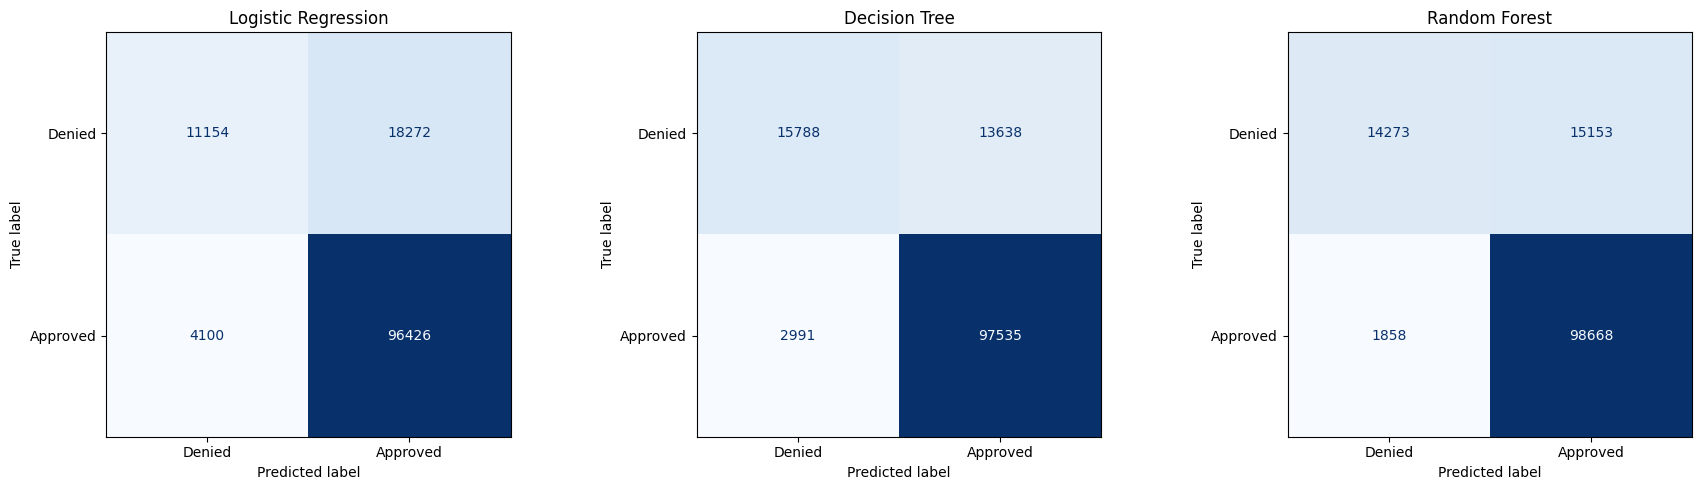

In [12]:
# Step 8: Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (model, X_eval)) in zip(axes, models.items()):
    pred_test = model.predict(X_eval)
    cm = confusion_matrix(y_test, pred_test)
    ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Approved']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

**Key Findings:**
- **Logistic Regression** correctly identifies 96,426 approved applications but misclassifies 18,272 denied applications as approved (false positives). This is the highest false positive count among the three models
- **Decision Tree** achieves a better balance, correctly identifying 15,788 denials while maintaining 97,535 correct approvals. It reduces false positives compared to Logistic Regression at the cost of slightly more false negatives (2,991)
- **Random Forest** has the fewest false negatives (1,858), i.e., the fewest approved applicants incorrectly denied, but allows 15,153 false positives
- In a lending context, the tradeoff between false positives (approving risky borrowers) and false negatives (denying creditworthy borrowers) has real consequences. False positives expose lenders to default risk, while false negatives represent lost business and potential fairness concernsx

### Step 9 | ROC Curves
We plot the ROC curve for each model. The ROC curve illustrates the tradeoff between the true positive rate and false positive rate at various classification thresholds. Higher AUC-ROC = better ability to discriminate between approved and denied applications

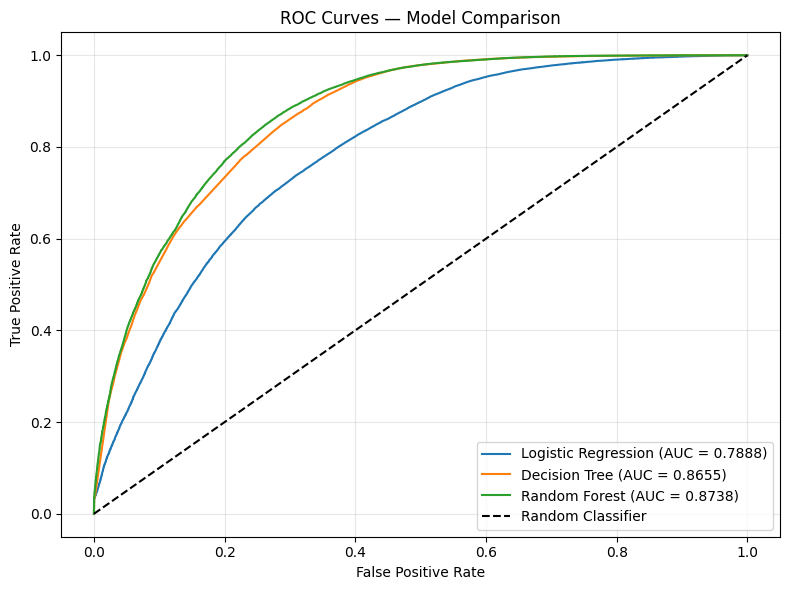

In [13]:
# Step 9: ROC Curves

plt.figure(figsize=(8, 6))

for name, (model, X_eval) in models.items():
    pred_test_prob = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, pred_test_prob)
    auc = roc_auc_score(y_test, pred_test_prob)
    plt.plot(fpr, tpr, label=name + ' (AUC = ' + str(round(auc, 4)) + ')')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Key Findings:**
- The ROC curves clearly separate the three models. Random Forest (green, AUC=0.8738) and Decision Tree (orange, AUC=0.8655) curve closer to the top-left corner, indicating superior discrimination ability across all classification thresholds
- Logistic Regression (blue, AUC=0.7888) shows notably weaker performance, particularly at lower false positive rates. It struggles more to identify denied applications without also misclassifying approved ones
- All three models substantially outperform a random classifier (diagonal dashed line), confirming that the feature set contains meaningful predictive signal for mortgage approval outcomes

### Step 10 | Feature Importance: Logistic Regression Coefficients
To understand which variables drive mortgage approval decisions, we examine the coefficients from the best Logistic Regression model. Because the features were standardized before fitting, the magnitude of each coefficient reflects its relative importance on a comparable scale. Positive coefficients indicate features associated with a higher probability of approval, while negative coefficients indicate features associated with a higher probability of denial. We display the top 20 most influential features by absolute coefficient magnitude.

Top 20 Features by |Coefficient|:
preapproval                      -0.9897
dti_ordinal                      -0.7516
aus_1                            -0.6239
loan_amount                       0.3783
loan_purpose                     -0.2341
construction_method              -0.2267
debt_to_income_ratio_missing     -0.1564
applicant_credit_score_type      -0.1278
property_value                   -0.1258
lien_status                       0.1258
conforming_loan_limit            -0.1081
business_or_commercial_purpose   -0.1029
balloon_payment                  -0.0885
state_code_FL                    -0.0811
total_units                      -0.0806
loan_term                        -0.0728
state_code_WI                     0.0726
occupancy_type                   -0.0715
interest_only_payment            -0.0670
state_code_TX                    -0.0640
dtype: float64


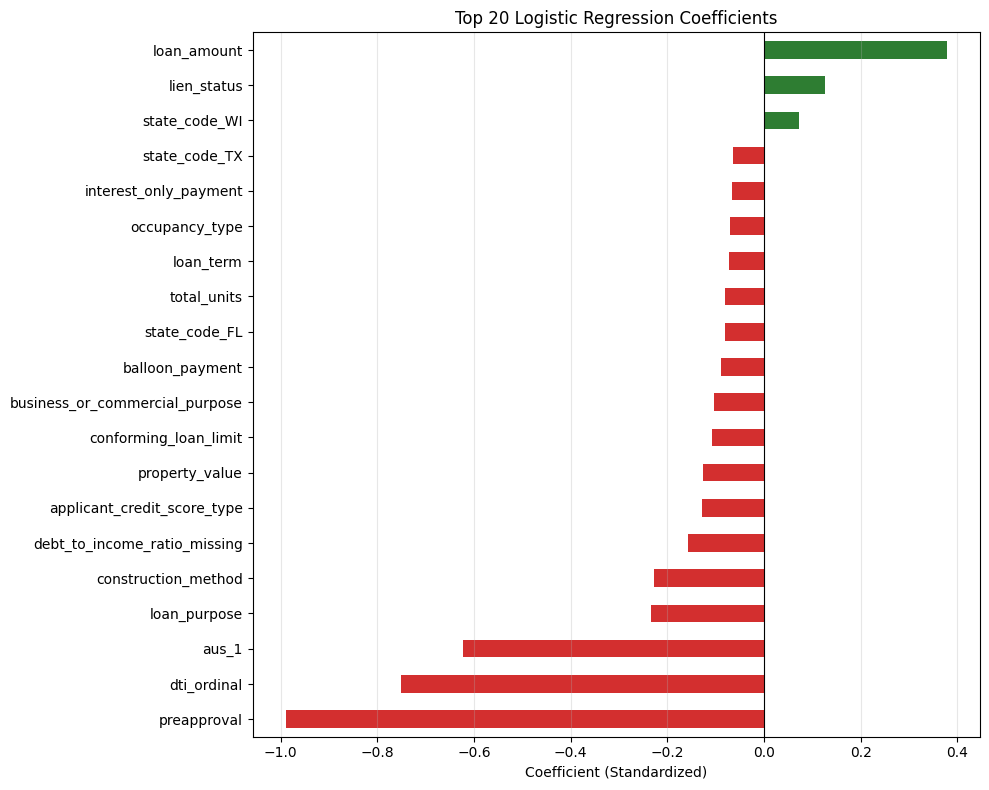

In [14]:
# Step 10: Logistic Regression Coefficients

lr_coefs = pd.Series(best_lr.coef_[0], index=X_train.columns)
lr_coefs_sorted = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=False).index)

print('Top 20 Features by |Coefficient|:')
print(lr_coefs_sorted.head(20).round(4))

# Plot top 20
top20 = lr_coefs_sorted.head(20).sort_values()
colors = ['#d32f2f' if c < 0 else '#2e7d32' for c in top20]

plt.figure(figsize=(10, 8))
top20.plot(kind='barh', color=colors)
plt.xlabel('Coefficient (Standardized)')
plt.title('Top 20 Logistic Regression Coefficients')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

**Key Findings:**
- **Preapproval** (-0.9897) is the strongest predictor: applicants without preapproval are substantially more likely to be denied. This is expected, as preapproval indicates a borrower has already undergone a preliminary screening
- **Debt-to-income ratio** (-0.7516) is the second strongest: higher DTI is strongly associated with denial. Borrowers carrying more debt relative to income are considered higher risk
- **Automated underwriting system** (-0.6239) is third, reflecting that the routing of applications through different underwriting platforms is associated with different approval probabilities
- **Loan amount** (0.3783) is the strongest positive predictor. Larger loans are associated with approval, likely because they correlate with higher-income, lower-risk borrowers
- Several state codes appear in the top 20 (FL, WI, TX), suggesting geographic variation in approval patterns that may reflect regional differences in lending standards or housing markets
- Importantly, all top predictors are financial and loan characteristics (not demographic variables, which were excluded) supporting the conclusion that the model's decisions are driven by economically meaningful risk factors

### Step 11 | Feature Importance: Random Forest
We extract the feature importances from the Random Forest model. These importances are based on the mean decrease in Gini impurity across all trees. Unlike Logistic Regression coefficients, they do not indicate the direction of the effect but measure each feature's contribution to the model's ability to separate approved from denied applications.

Top 20 Features by Importance:
dti_ordinal                             0.3667
aus_1                                   0.0919
income                                  0.0772
loan_purpose                            0.0739
combined_loan_to_value_ratio            0.0557
debt_to_income_ratio_missing            0.0361
loan_amount                             0.0359
applicant_credit_score_type             0.0350
property_value                          0.0312
construction_method                     0.0312
loan_term                               0.0281
loan_type                               0.0199
combined_loan_to_value_ratio_missing    0.0174
lien_status                             0.0168
open_end_line_of_credit                 0.0144
age_ordinal                             0.0120
occupancy_type                          0.0061
business_or_commercial_purpose          0.0050
preapproval                             0.0042
balloon_payment                         0.0040
dtype: float64


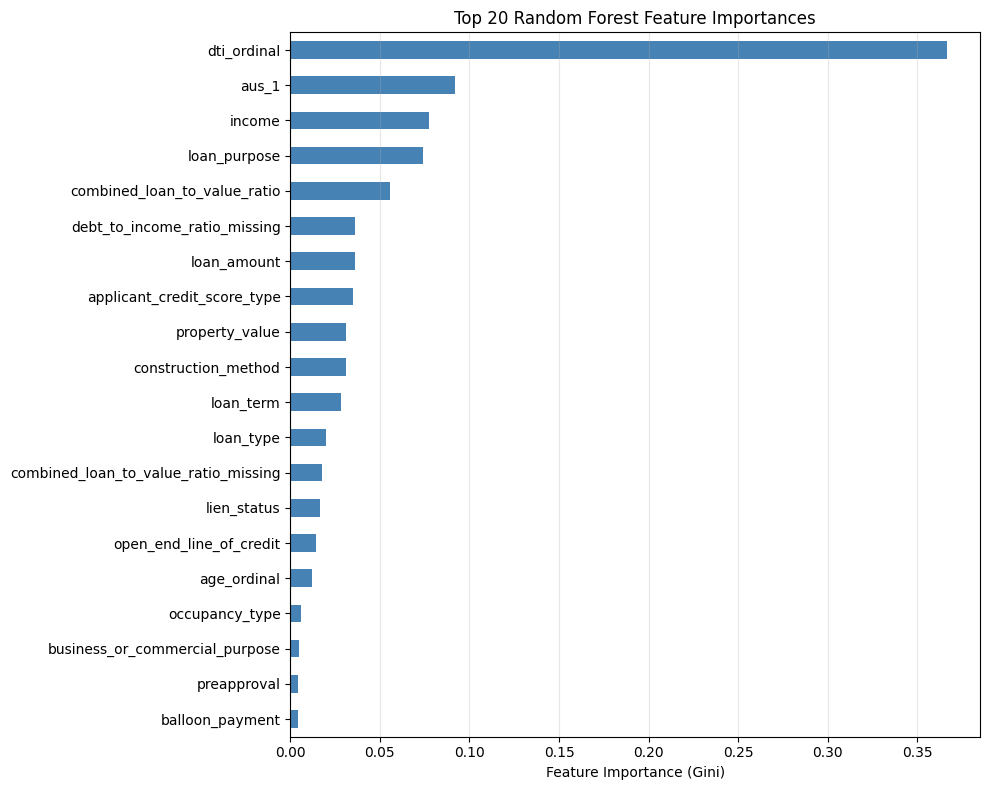

In [15]:
# Step 11: Random Forest Feature Importances

rf_importances = pd.Series(best_forest.feature_importances_, index=X_train.columns)
rf_importances = rf_importances.sort_values(ascending=False)

print('Top 20 Features by Importance:')
print(rf_importances.head(20).round(4))

# Plot top 20
plt.figure(figsize=(10, 8))
rf_importances.head(20).sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance (Gini)')
plt.title('Top 20 Random Forest Feature Importances')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

**Key Findings:**
- **Debt-to-income ratio** (0.3667) dominates Random Forest feature importance, accounting for more than three times the importance of any other feature. This confirms DTI as the single most important driver of mortgage approval decisions
- **Automated underwriting system** (0.0919) and **income** (0.0772) are second and third, reinforcing the importance of financial characteristics
- Unlike Logistic Regression where preapproval was #1, it ranks near the bottom here (0.0042)
- Continuous financial variables (income, combined loan-to-value ratio, property value, loan amount) feature prominently in the Random Forest rankings. This suggests these variables have nonlinear effects on approval that the tree-based model captures effectively

### Step 12 | Combined Feature Importance Comparison
We compare the top features identified by Logistic Regression (by absolute coefficient) and Random Forest (by Gini importance) side by side. Features that rank highly in both models can be considered robustly important regardless of the modeling approach.

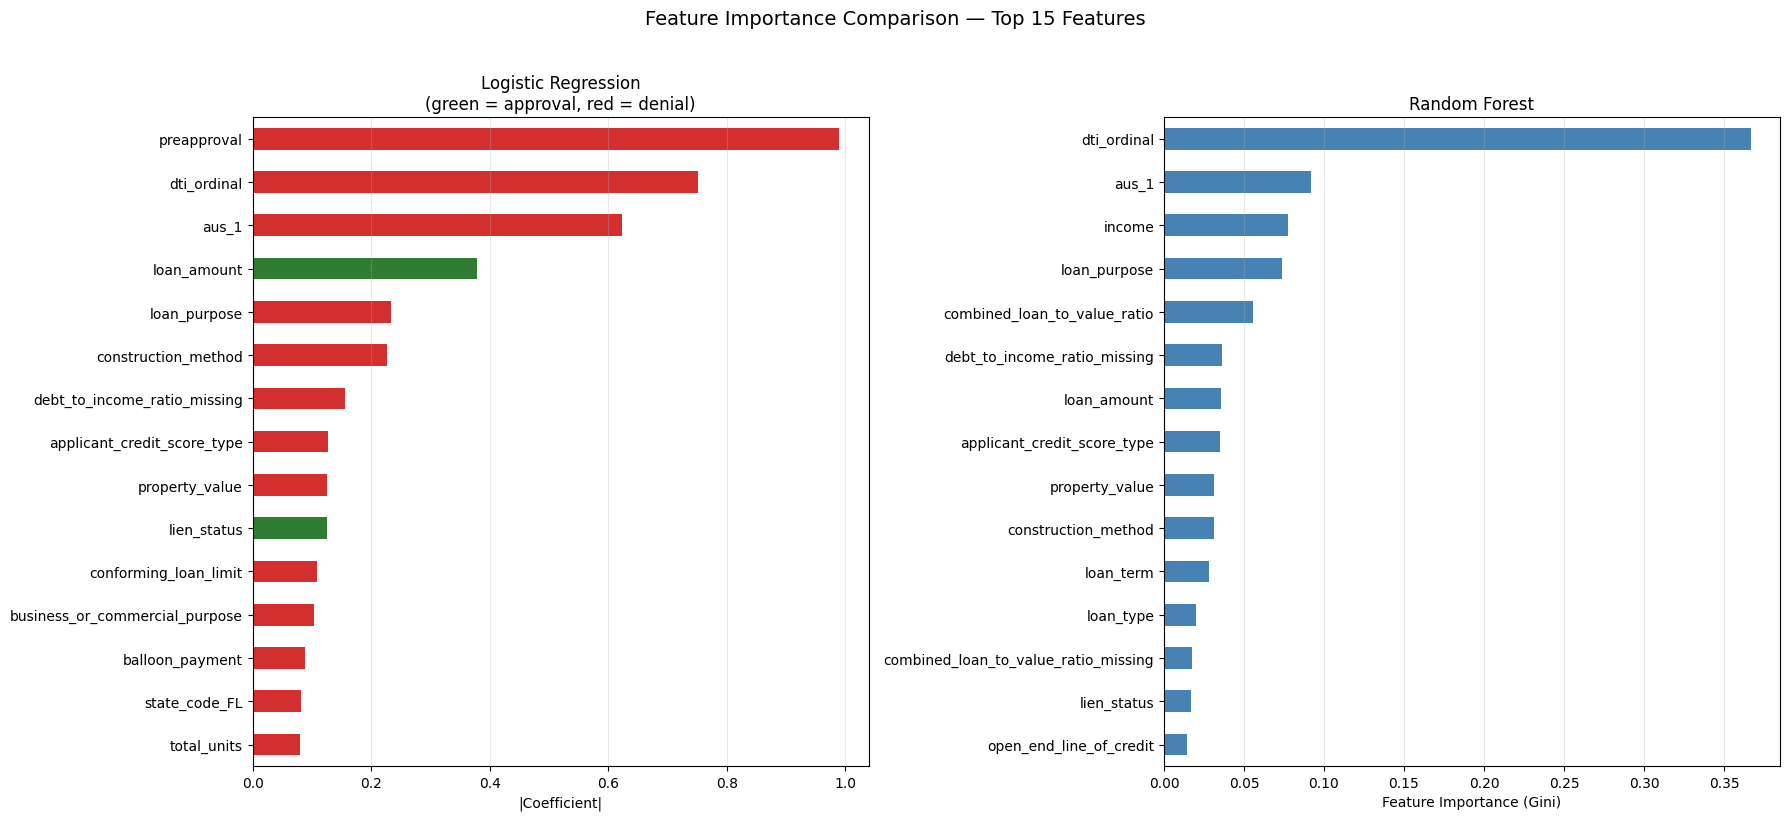

Features in top 15 of BOTH models (9):
  - applicant_credit_score_type
  - aus_1
  - construction_method
  - debt_to_income_ratio_missing
  - dti_ordinal
  - lien_status
  - loan_amount
  - loan_purpose
  - property_value


In [16]:
# Step 12: Side-by-Side Feature Importance Comparison

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Logistic Regression - Top 15
top15_lr = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=False).head(15).index)
top15_lr_plot = top15_lr.sort_values(key=abs)
colors_lr = ['#d32f2f' if c < 0 else '#2e7d32' for c in top15_lr_plot]
top15_lr_plot.abs().plot(kind='barh', color=colors_lr, ax=axes[0])
axes[0].set_xlabel('|Coefficient|')
axes[0].set_title('Logistic Regression\n(green = approval, red = denial)')
axes[0].grid(alpha=0.3, axis='x')

# Random Forest - Top 15
rf_importances.head(15).sort_values().plot(kind='barh', color='steelblue', ax=axes[1])
axes[1].set_xlabel('Feature Importance (Gini)')
axes[1].set_title('Random Forest')
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Feature Importance Comparison — Top 15 Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Overlap analysis
top15_lr_set = set(lr_coefs.abs().sort_values(ascending=False).head(15).index)
top15_rf_set = set(rf_importances.head(15).index)
overlap = top15_lr_set & top15_rf_set

print('Features in top 15 of BOTH models (' + str(len(overlap)) + '):')
for f in sorted(overlap):
    print('  -', f)

**Key Findings:**
- Both models agree that **debt-to-income ratio** and the **automated underwriting system** are among the top lending drivers, making these the most robustly important features in the dataset
- The models diverge in how they rank other features: Logistic Regression emphasizes categorical variables like preapproval and construction method, while Random Forest prioritizes continuous financial variables like income, CLTV and property value
- The overlap of 9 features in the top 15 of both models provides confidence that the identified lending drivers reflect genuine patterns in the data

### Step 13 | Summary and Key Findings
We summarize the results from the model comparison and feature importance analysis.

In [17]:
# Step 13: Summary

print('='*60)
print('RQ1 SUMMARY: Predictive Performance & Key Lending Drivers')
print('='*60)

print('\n1. MODEL PERFORMANCE (Test Set):')
print(results_df.round(4))

best_model_name = results_df['AUC-ROC'].idxmax()
best_auc = results_df['AUC-ROC'].max()
print('\nBest model by AUC-ROC:', best_model_name, '(' + str(round(best_auc, 4)) + ')')

print('\n2. TOP 10 LENDING DRIVERS (Logistic Regression |coefficient|):')
top10_lr = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=False).head(10).index)
for feat, coef in top10_lr.items():
    direction = 'approval' if coef > 0 else 'denial'
    print('  ', feat, '-> coef:', round(coef, 4), '(favors', direction + ')')

print('\n3. TOP 10 LENDING DRIVERS (Random Forest importance):')
for feat, imp in rf_importances.head(10).items():
    print('  ', feat, '-> importance:', round(imp, 4))

print('\n4. KEY TAKEAWAYS:')
print('  - All models trained WITHOUT demographic variables (race, ethnicity, sex)')
print('  - interest_rate_missing was excluded as it is structurally determined by the outcome')
print('  -', best_model_name, 'achieved the highest AUC-ROC on the test set')
print('  -', len(overlap), 'of the top 15 features overlap between LR and RF')
print('  - These results feed into RQ2 (fairness audit) and the final report')

RQ1 SUMMARY: Predictive Performance & Key Lending Drivers

1. MODEL PERFORMANCE (Test Set):
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.8278     0.8407  0.9592    0.8961   0.7888
Decision Tree          0.8720     0.8773  0.9702    0.9214   0.8655
Random Forest          0.8691     0.8669  0.9815    0.9206   0.8738

Best model by AUC-ROC: Random Forest (0.8738)

2. TOP 10 LENDING DRIVERS (Logistic Regression |coefficient|):
   preapproval -> coef: -0.9897 (favors denial)
   dti_ordinal -> coef: -0.7516 (favors denial)
   aus_1 -> coef: -0.6239 (favors denial)
   loan_amount -> coef: 0.3783 (favors approval)
   loan_purpose -> coef: -0.2341 (favors denial)
   construction_method -> coef: -0.2267 (favors denial)
   debt_to_income_ratio_missing -> coef: -0.1564 (favors denial)
   applicant_credit_score_type -> coef: -0.1278 (favors denial)
   property_value -> coef: -0.1258 (

**Summary:** 
- Our best model (Random Forest) achieved an AUC-ROC of 0.8738 using only application-time features, demonstrating that approval outcomes are substantially predictable from historical data (even without credit scores)
- Lending decisions are primarily driven by financially meaningful risk factors. Debt-to-income ratio emerged as the dominant predictor across both modeling approaches, followed by the automated underwriting system, income, loan amount and combined loan-to-value ratio. These are all standard measures of borrower risk, suggesting that approval decisions largely align with economic fundamentals
- Nonlinear relationships play an important role. The substantial performance gap between Logistic Regression (AUC 0.79) and the tree-based models (AUC 0.87) indicates that the relationship between borrower characteristics and approval is not simply linear
- Demographic variables are not needed for strong predictive performance. All models were trained without information on race, ethnicity or sex, yet still achieved meaningful accuracy. This does not mean demographic disparities don't exist, but it confirms that some predictive signal in the data comes from financial and loan characteristics